# Part 2: Track Characteristics - Exploratory Data Analysis (EDA)

## Overview
Following the driver demographics, this notebook focuses on the physical and telemetry-based characteristics of different Formula 1 tracks. Since each circuit possesses a unique layout, comparing raw telemetry data directly across different tracks can introduce significant "Track Bias." 

## Objectives
* Analyze speed distributions, braking zones, and cornering profiles across various circuits.
* Highlight the distinct nature of each track (e.g., high-speed vs. highly technical tracks).
* Establish the mathematical justification for data normalization in our upcoming clustering pipeline.

### 1. Speed Analysis Across Tracks
In this graph, we examine the average and median speeds for each track. As we can see, there is a significant gap between high-speed tracks like Monza—often called the "Temple of Speed"—and slow, technical street circuits like Singapore. This gap highlights the necessity of normalizing our data on a per-corner basis to avoid Track Bias in our clustering algorithm.

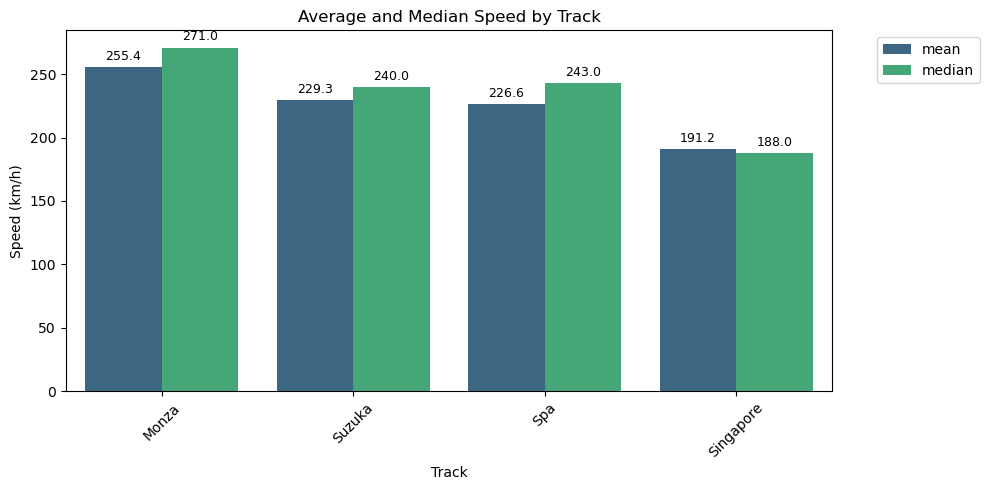

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../processed_data/golden_laps_final.csv')

def add_labels(ax, fmt='%.1f'):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=3, fontsize=9)

# 1. Average and Median Speed by Track
speed_stats = df.groupby('Track')['speed'].agg(['mean', 'median']).reset_index()
speed_melted = pd.melt(speed_stats, id_vars='Track', var_name='Metric', value_name='Speed')
track_order = speed_stats.sort_values('mean', ascending=False)['Track'].tolist()

plt.figure(figsize=(10, 5))
ax1 = sns.barplot(data=speed_melted, x='Track', y='Speed', hue='Metric', palette='viridis', order=track_order)
plt.title('Average and Median Speed by Track')
plt.ylabel('Speed (km/h)')
plt.xticks(rotation=45)
add_labels(ax1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 2. Throttle Application Percentage
The acceleration profile is directly correlated with the nature of the track. On fast, flowing circuits with long straights, drivers spend much more time with the throttle fully open. This graph clearly shows the dominance of full throttle in Monza compared to the other tracks.

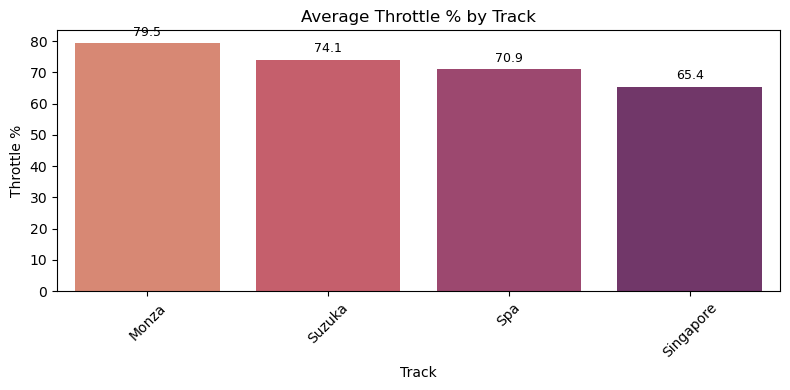

In [6]:
# 2. Average Throttle % by Track
avg_thr = df.groupby('Track')['throttle'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 4))
# Note: Using hue='Track' and legend=False prevents the seaborn FutureWarning
ax2 = sns.barplot(data=avg_thr, x='Track', y='throttle', hue='Track', palette='flare', legend=False)
plt.title('Average Throttle % by Track')
plt.ylabel('Throttle %')
plt.xticks(rotation=45)
add_labels(ax2)
plt.tight_layout()
plt.show()

### 3. Track Braking Percentage
This graph presents the percentage of lap time drivers spend applying the brakes. The Singapore street circuit requires the highest braking percentage due to its numerous sharp 90-degree turns. In contrast, at Spa and Monza, braking zones are aggressive but brief, focused primarily at the end of long straights.

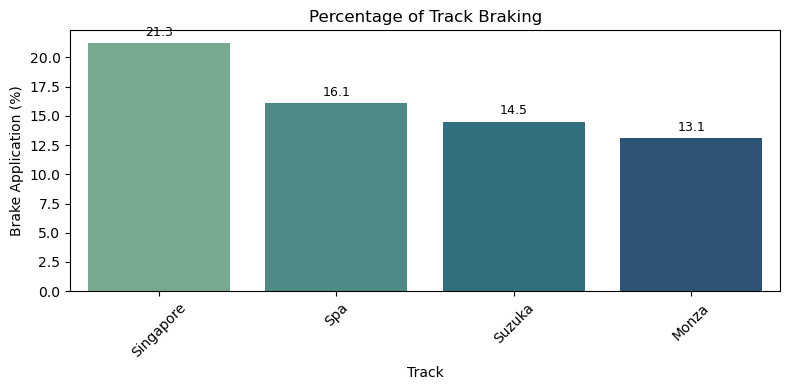

In [7]:
# 3. Percentage of Track Braking
df['is_braking'] = df['brake'] > 0
brake_pct = (df.groupby('Track')['is_braking'].mean() * 100).sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 4))
ax3 = sns.barplot(data=brake_pct, x='Track', y='is_braking', hue='Track', palette='crest', legend=False)
plt.title('Percentage of Track Braking')
plt.ylabel('Brake Application (%)')
plt.xticks(rotation=45)
add_labels(ax3)
plt.tight_layout()
plt.show()

### 4. Average Lap Times
Lap time depends primarily on the physical length of the circuit. Spa in Belgium is the longest track on the Formula 1 calendar (over 7 km per lap), which is why its lap times are the highest, despite the incredibly high average speeds achieved there.

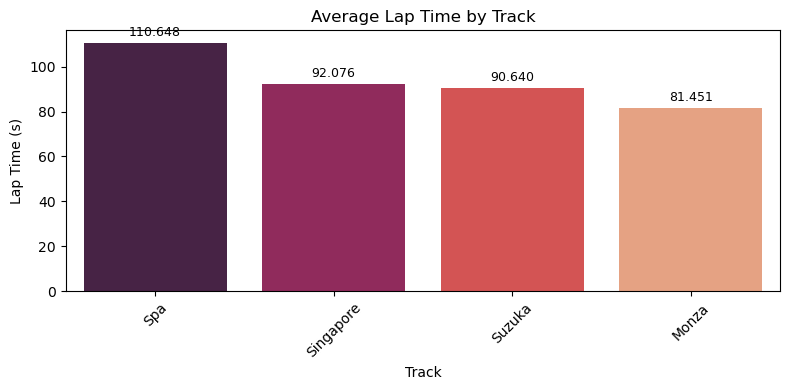

In [8]:
# 4. Average Lap Time by Track
laps = df[['Track', 'driver_number', 'Lap_Time']].drop_duplicates()
avg_lap = laps.groupby('Track')['Lap_Time'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 4))
ax4 = sns.barplot(data=avg_lap, x='Track', y='Lap_Time', hue='Track', palette='rocket', legend=False)
plt.title('Average Lap Time by Track')
plt.ylabel('Lap Time (s)')
plt.xticks(rotation=45)
add_labels(ax4, fmt='%.3f')
plt.tight_layout()
plt.show()